In [1]:
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
# -----------------------------
# Parameters
# -----------------------------

N = 1000                 # number of spins
J = 1                  # coupling (1 ferro, -1 antiferro)
beta = 4                # inverse temperature
N_steps = 100_000

# -----------------------------
# Initial states
# -----------------------------

def init_state(kind="hot"):
    
    if kind == "hot":
        return np.random.choice([-1,1], size=N)

    if kind == "ferro":
        return np.ones(N)

    if kind == "antiferro":
        return np.array([(-1)**i for i in range(N)])


# -----------------------------
# Energy
# -----------------------------

def energy(S):

    return -J * np.sum(S * np.roll(S,-1)) / 2


# -----------------------------
# Magnetization
# -----------------------------

def magnetization(S):
    return np.sum(S)/N


# -----------------------------
# Single Metropolis step
# -----------------------------

def mc_step(S,beta):

    i = np.random.randint(N)

    # energy change if flipped
    dE = 2*J*S[i]*(S[(i-1)%N] + S[(i+1)%N])

    if dE <= 0 or np.random.rand() < np.exp(-beta*dE):
        S[i] *= -1

    return S


# -----------------------------
# Simulation
# -----------------------------

def run_simulation(S0,beta,N_steps):

    S = S0.copy()

    E_list=[]
    M_list=[]

    for _ in range(N_steps):

        S = mc_step(S,beta)

        E_list.append(energy(S))
        M_list.append(magnetization(S))

    return S,np.array(E_list),np.array(M_list)

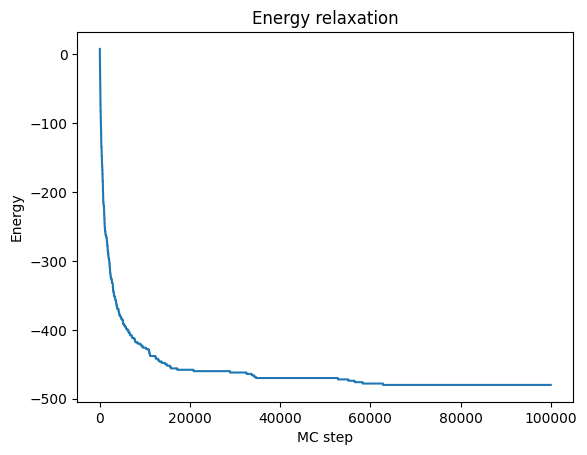

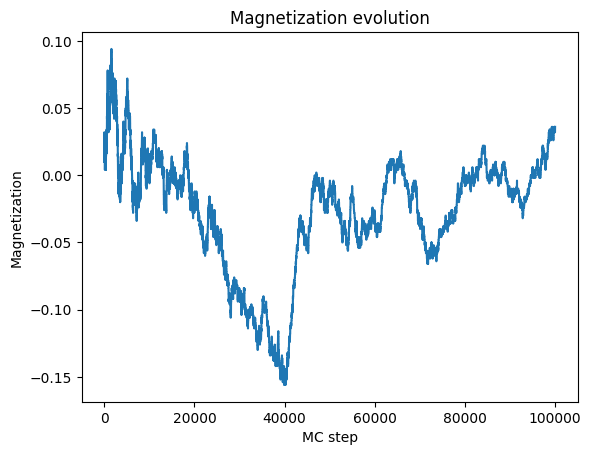

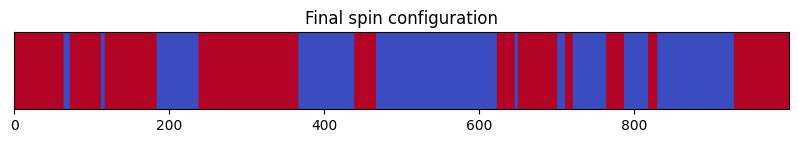

In [3]:
S0 = init_state("hot")

S,E,M = run_simulation(S0,beta,N_steps)

plt.figure()
plt.plot(E)
plt.xlabel("MC step")
plt.ylabel("Energy")
plt.title("Energy relaxation")
plt.show()

plt.figure()
plt.plot(M)
plt.xlabel("MC step")
plt.ylabel("Magnetization")
plt.title("Magnetization evolution")
plt.show()

plt.figure(figsize=(10,1))
plt.imshow(S.reshape(1,-1), cmap="coolwarm", aspect="auto")
plt.yticks([])
plt.title("Final spin configuration")
plt.show()

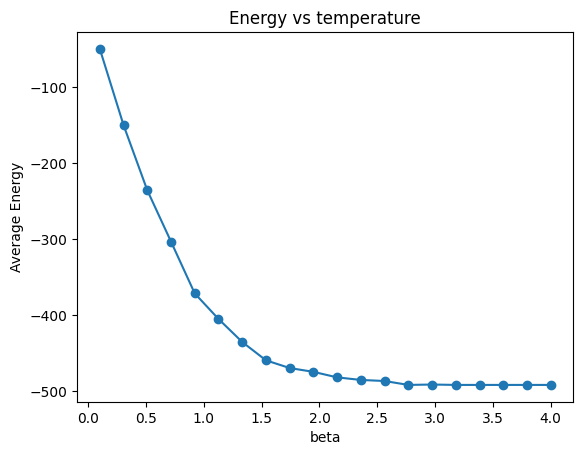

In [4]:
betas = np.linspace(0.1,4,20)

E_avg=[]
M_avg=[]

S = init_state("hot")
for b in betas:

    S,E,M = run_simulation(S,b,N_steps) #gradual cooling steps

    E_avg.append(np.mean(E[-int(N_steps/2):]))
    M_avg.append(np.mean(np.abs(M[-int(N_steps/2):])))

plt.figure()
plt.plot(betas,E_avg,'o-')
plt.xlabel("beta")
plt.ylabel("Average Energy")
plt.title("Energy vs temperature")
plt.show()